# Importing libraries

In [1]:
import pandas as pd   # data analysis and manipulation tools
import numpy as np    # multi-dimensional arrays and matrices
import seaborn as sns # data visualization

# Importing the dataset

In [2]:
df = pd.read_csv('data/03-bank.csv')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Columns: 292 entries, id to price_doc
dtypes: float64(119), int64(157), object(16)
memory usage: 67.9+ MB
None


In [3]:
df.describe()

,id,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
count,30471.000000,30471.000000,24088.000000,30304.000000,20899.000000,20899.000000,1.686600e+04,20899.000000,20899.000000,16912.000000,...,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,3.047100e+04
mean,15237.917397,54.214269,34.403271,7.670803,12.558974,1.827121,3.068057e+03,1.909804,6.399301,2.107025,...,32.058318,10.783860,1.771783,15.045552,30.251518,0.442421,8.648814,52.796593,5.987070,7.123035e+06
std,8796.501536,38.031487,52.285733,5.319989,6.756550,1.481154,1.543878e+05,0.851805,28.265979,0.880148,...,73.465611,28.385679,5.418807,29.118668,47.347938,0.609269,20.580741,46.292660,4.889219,4.780111e+06
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+05
25%,7620.500000,38.000000,20.000000,3.000000,9.000000,1.000000,1.967000e+03,1.000000,1.000000,1.000000,...,2.000000,1.000000,0.000000,2.000000,9.000000,0.000000,0.000000,11.000000,1.000000,4.740002e+06
50%,15238.000000,49.000000,30.000000,6.500000,12.000000,1.000000,1.979000e+03,2.000000,6.000000,2.000000,...,8.000000,2.000000,0.000000,7.000000,16.000000,0.000000,2.000000,48.000000,5.000000,6.274411e+06
75%,22855.500000,63.000000,43.000000,11.000000,17.000000,2.000000,2.005000e+03,2.000000,9.000000,3.000000,...,21.000000,5.000000,1.000000,12.000000,28.000000,1.000000,7.000000,76.000000,10.000000,8.300000e+06
max,30473.000000,5326.000000,7478.000000,77.000000,117.000000,6.000000,2.005201e+07,19.000000,2014.000000,33.000000,...,377.000000,147.000000,30.000000,151.000000,250.000000,2.000000,106.000000,218.000000,21.000000,1.111111e+08


In [4]:
df.describe(include='object')

,timestamp,product_type,sub_area,culture_objects_top_25,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,water_1line,big_road1_1line,railroad_1line,ecology
count,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471
unique,1161,2,146,2,2,2,2,2,2,2,2,2,2,2,2,5
top,2014-12-16,Investment,Poselenie Sosenskoe,no,no,no,no,no,no,no,no,no,no,no,no,poor
freq,160,19448,1776,28543,28817,28155,30175,19600,29335,27649,29608,27427,28134,29690,29578,8018


# Missing data

### Missing values detection

In [5]:
# Percentage list for missing values
for col in df.columns:
    pct_missing = np.mean(df[col].isna())
    
    if pct_missing>0.2: # show the features with more than 20% missing values
        print('{} - {}%'.format(col, round(pct_missing*100)))

life_sq - 21%
max_floor - 31%
material - 31%
build_year - 45%
num_room - 31%
kitch_sq - 31%
state - 44%
preschool_quota - 22%
school_quota - 22%
hospital_beds_raion - 47%
cafe_sum_500_min_price_avg - 44%
cafe_sum_500_max_price_avg - 44%
cafe_avg_price_500 - 44%
cafe_sum_1000_min_price_avg - 21%
cafe_sum_1000_max_price_avg - 21%
cafe_avg_price_1000 - 21%


<Axes: xlabel='num_missing'>

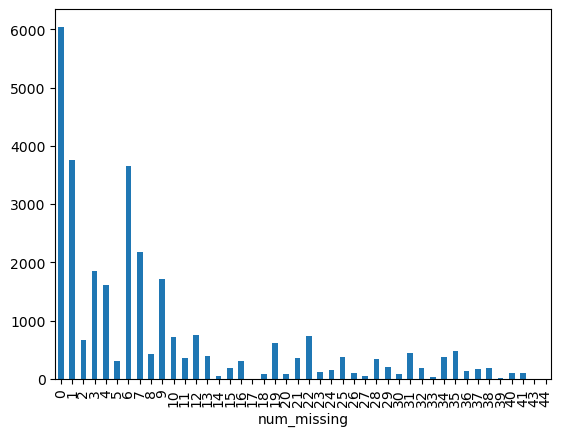

In [6]:
# Add the indicator of missing values
for col in df.columns:
    missing = df[col].isna()
    num_missing = np.sum(missing)
    
    if num_missing > 0:  
        # create the missing value indicator variables 
        df['{}_ismissing'.format(col)] = missing

# Build histogram
ismissing_cols = [col for col in df.columns if 'ismissing' in col]
df['num_missing'] = df[ismissing_cols].sum(axis=1)

df['num_missing'].value_counts().sort_index().plot.bar()

<Axes: >

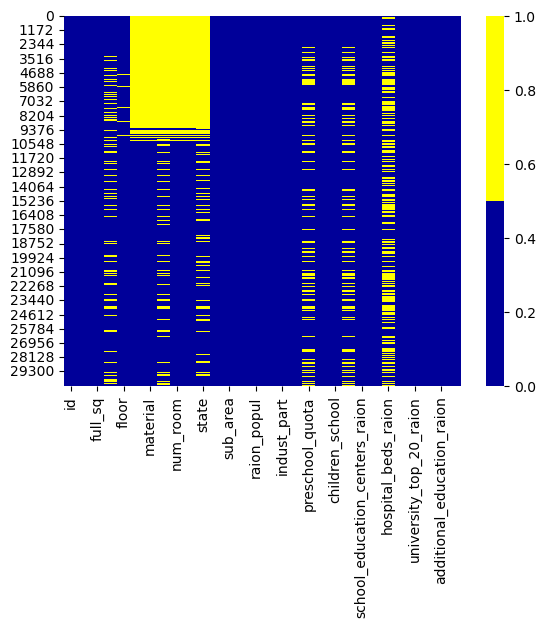

In [7]:
cols = df.columns[:30] # cut the first 30 columns

# Define the color: yellow reflects the missing data, blue reflects complete data 
colours = ['#000099', '#ffff00'] 
sns.heatmap(df[cols].isnull(), cmap=sns.color_palette(colours))

## Dealing with missing data

In [8]:
# Drop the rows with many missing values

ind_missing = df[df['num_missing'] > 35].index
df_less_missing_rows = df.drop(ind_missing, axis=0)

print(df_less_missing_rows.shape)

(29779, 344)


In [9]:
# Drop the feature 'hospital_beds_raion' (47% of missing values)

df_less_hos_beds_raion = df.drop('hospital_beds_raion', axis=1)

print(df_less_hos_beds_raion.shape)

(30471, 343)


In [10]:
# Imput the missig values with mediana

med = df['life_sq'].median()
print(med)

df['life_sq'] = df['life_sq'].fillna(med)
print(df.shape)

30.0
(30471, 344)


In [11]:
# Impute the missing values for each numeric column.
df_numeric = df.select_dtypes(include=[np.number])
numeric_cols = df_numeric.columns.values

for col in numeric_cols:
    missing = df[col].isna()
    num_missing = np.sum(missing)
    
    # only do the imputation for the columns that have missing values
    if num_missing > 0:  
        # print('imputing missing values for: {}'.format(col))
        med = df[col].median()
        df[col] = df[col].fillna(med)
        
print(df.shape)

(30471, 344)


In [12]:
# Replace the missing data

# categorical feature
df['sub_area'] = df['sub_area'].fillna('_MISSING_')

# numerical feature
df['life_sq'] = df['life_sq'].fillna(-999)

# Outliers

## Outliers detection

<Axes: >

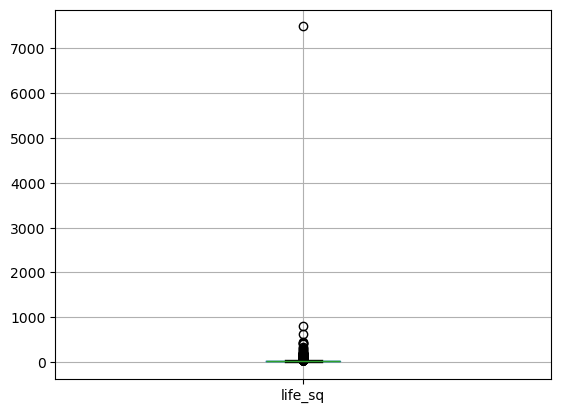

In [13]:
# Boxplot

df.boxplot(column=['life_sq'])

In [14]:
# Descriptive statistics

df['life_sq'].describe()

count    30471.000000
mean        33.480883
std         46.522251
min          0.000000
25%         22.000000
50%         30.000000
75%         38.000000
max       7478.000000
Name: life_sq, dtype: float64

## Dealing with outlers
See techniques for dealing with missing values

# Data Cleaning

## Duplicated records detection

In [15]:
# drop not-unique rows
df_dedupped = df.drop('id', axis=1).drop_duplicates()

# compare the dataframe dimentions
print(df.shape)
print(df_dedupped.shape)

(30471, 344)
(30461, 343)


## Dealing with duplicated data

In [16]:
# Data duplicated on key features

key = ['timestamp', 'full_sq', 'life_sq', 'floor', 'build_year', 
       'num_room', 'price_doc']

df.fillna(-999).groupby(key)['id'].count().sort_values(ascending=False).head(20)

timestamp   full_sq  life_sq  floor  build_year  num_room  price_doc
2013-04-03  42       30.0     2.0    1979.0      2.0       3444000      2
2012-10-22  61       30.0     18.0   1979.0      2.0       8248500      2
2012-09-05  43       30.0     21.0   1979.0      2.0       6229540      2
2013-06-24  40       30.0     12.0   1979.0      2.0       4112800      2
2013-09-23  85       30.0     14.0   1979.0      3.0       7725974      2
2014-01-22  46       28.0     1.0    1968.0      2.0       3000000      2
2013-05-22  68       30.0     2.0    1979.0      2.0       5406690      2
2013-12-05  40       30.0     5.0    1979.0      1.0       4414080      2
2013-08-30  40       30.0     12.0   1979.0      1.0       4462000      2
2013-12-18  39       30.0     6.0    1979.0      1.0       3700946      2
2012-08-27  59       30.0     6.0    1979.0      2.0       4506800      2
2014-04-15  134      134.0    1.0    0.0         3.0       5798496      2
2014-12-09  40       30.0     17.0   1979.0

In [17]:
key = ['timestamp', 'full_sq', 'life_sq', 'floor', 'build_year', 
       'num_room', 'price_doc']
df_dedupped2 = df.drop_duplicates(subset=key)

print(df.shape)
print(df_dedupped2.shape)

(30471, 344)
(30455, 344)


## Read new dataset

In [18]:
df = pd.read_csv('data/03-online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Type conversion

In [19]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(str)

In [20]:
df['year'] = df['InvoiceDate'].dt.year
df['month'] = df['InvoiceDate'].dt.month
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12


# Data Transformation

## Importing the datasets

In [21]:
calls = pd.read_csv("data/03-sales_calls.csv")
print(calls)

revenue = pd.read_csv("data/03-sales_revenue.csv")
print(revenue)

  Team member  Territory  Month  Calls
0       Jorge          3      1    107
1       Jorge          3      2     88
2       Jorge          3      3     84
3       Jorge          3      4    113
4         Ana          1      1     91
5         Ana          1      2    129
6         Ana          1      3     96
7         Ana          1      4    128
8         Ali          2      1    120
9         Ali          2      2     85
   Territory  Month  Amount
0          1      1   54228
1          1      2   61640
2          1      3   43491
3          1      4   52173
4          2      1   36061
5          2      2   44957
6          2      3   35058
7          2      4   33855
8          3      1   50876
9          3      2   57682


## Combining data

In [22]:
# Appending dataframes
print(pd.concat([calls, revenue]))

  Team member  Territory  Month  Calls   Amount
0       Jorge          3      1  107.0      NaN
1       Jorge          3      2   88.0      NaN
2       Jorge          3      3   84.0      NaN
3       Jorge          3      4  113.0      NaN
4         Ana          1      1   91.0      NaN
5         Ana          1      2  129.0      NaN
6         Ana          1      3   96.0      NaN
7         Ana          1      4  128.0      NaN
8         Ali          2      1  120.0      NaN
9         Ali          2      2   85.0      NaN
0         NaN          1      1    NaN  54228.0
1         NaN          1      2    NaN  61640.0
2         NaN          1      3    NaN  43491.0
3         NaN          1      4    NaN  52173.0
4         NaN          2      1    NaN  36061.0
5         NaN          2      2    NaN  44957.0
6         NaN          2      3    NaN  35058.0
7         NaN          2      4    NaN  33855.0
8         NaN          3      1    NaN  50876.0
9         NaN          3      2    NaN  

In [23]:
# Merging dataframes
calls_revenue = pd.merge(calls, revenue, on=['Territory', 'Month'])
print(calls_revenue)

  Team member  Territory  Month  Calls  Amount
0       Jorge          3      1    107   50876
1       Jorge          3      2     88   57682
2         Ana          1      1     91   54228
3         Ana          1      2    129   61640
4         Ana          1      3     96   43491
5         Ana          1      4    128   52173
6         Ali          2      1    120   36061
7         Ali          2      2     85   44957


In [24]:
pd.merge(calls, revenue) # merging by default with 'iner'

,Team member,Territory,Month,Calls,Amount
0,Jorge,3,1,107,50876
1,Jorge,3,2,88,57682
2,Ana,1,1,91,54228
3,Ana,1,2,129,61640
4,Ana,1,3,96,43491
5,Ana,1,4,128,52173
6,Ali,2,1,120,36061
7,Ali,2,2,85,44957


In [25]:
pd.merge(calls, revenue, how='outer') # merging with 'outer'

,Team member,Territory,Month,Calls,Amount
0,Ana,1,1,91.0,54228.0
1,Ana,1,2,129.0,61640.0
2,Ana,1,3,96.0,43491.0
3,Ana,1,4,128.0,52173.0
4,Ali,2,1,120.0,36061.0
5,Ali,2,2,85.0,44957.0
6,NaN,2,3,NaN,35058.0
7,NaN,2,4,NaN,33855.0
8,Jorge,3,1,107.0,50876.0
9,Jorge,3,2,88.0,57682.0


In [26]:
# Selecting data
print(calls_revenue[calls_revenue.Territory==3])

  Team member  Territory  Month  Calls  Amount
0       Jorge          3      1    107   50876
1       Jorge          3      2     88   57682


In [27]:
# Selecting data with calculated condition
print(calls_revenue[calls_revenue.Amount/calls_revenue.Calls>500])

  Team member  Territory  Month  Calls  Amount
1       Jorge          3      2     88   57682
2         Ana          1      1     91   54228
7         Ali          2      2     85   44957


In [28]:
# New calculated columns for dataframe
calls_revenue['Call_Amount'] = calls_revenue.Amount/calls_revenue.Calls
print(calls_revenue)

  Team member  Territory  Month  Calls  Amount  Call_Amount
0       Jorge          3      1    107   50876   475.476636
1       Jorge          3      2     88   57682   655.477273
2         Ana          1      1     91   54228   595.912088
3         Ana          1      2    129   61640   477.829457
4         Ana          1      3     96   43491   453.031250
5         Ana          1      4    128   52173   407.601562
6         Ali          2      1    120   36061   300.508333
7         Ali          2      2     85   44957   528.905882


In [29]:
# Getting all of the rows in which the amount per call is above the median
# (combining data)
print(calls_revenue.Call_Amount.median())
print(calls_revenue[calls_revenue.Call_Amount >= calls_revenue.Call_Amount.median()])

476.6530464391799
  Team member  Territory  Month  Calls  Amount  Call_Amount
1       Jorge          3      2     88   57682   655.477273
2         Ana          1      1     91   54228   595.912088
3         Ana          1      2    129   61640   477.829457
7         Ali          2      2     85   44957   528.905882


## Aggregation with GroupBy

In [30]:
calls_revenue.groupby('Team member')

In [31]:
calls_revenue.groupby('Team member')['Calls'].median()

Team member
Ali      102.5
Ana      112.0
Jorge     97.5
Name: Calls, dtype: float64

In [32]:
# The total calls and amounts by month...
print(calls_revenue[['Month', 'Calls', 'Amount']].groupby(['Month']).sum())

# ... and by territory
print(calls_revenue[['Territory', 'Calls', 'Amount']].groupby(['Territory']).sum())

       Calls  Amount
Month               
1        318  141165
2        302  164279
3         96   43491
4        128   52173
           Calls  Amount
Territory               
1            444  211532
2            205   81018
3            195  108558


In [33]:
# Iteration over groups

for (member, group) in calls_revenue.groupby('Team member'):
    print("{0:8s} shape={1}".format(member, group.shape))
    print(group)

Ali      shape=(2, 6)
  Team member  Territory  Month  Calls  Amount  Call_Amount
6         Ali          2      1    120   36061   300.508333
7         Ali          2      2     85   44957   528.905882
Ana      shape=(4, 6)
  Team member  Territory  Month  Calls  Amount  Call_Amount
2         Ana          1      1     91   54228   595.912088
3         Ana          1      2    129   61640   477.829457
4         Ana          1      3     96   43491   453.031250
5         Ana          1      4    128   52173   407.601562
Jorge    shape=(2, 6)
  Team member  Territory  Month  Calls  Amount  Call_Amount
0       Jorge          3      1    107   50876   475.476636
1       Jorge          3      2     88   57682   655.477273


In [34]:
# Aggregation
calls_revenue.groupby('Team member').aggregate(['min', 'median', 'max'])

Territory            Month            Calls             Amount  \
                  min median max   min median max   min median  max    min   
Team member                                                                  
Ali                 2    2.0   2     1    1.5   2    85  102.5  120  36061   
Ana                 1    1.0   1     1    2.5   4    91  112.0  129  43491   
Jorge               3    3.0   3     1    1.5   2    88   97.5  107  50876   

                            Call_Amount                          
              median    max         min      median         max  
Team member                                                      
Ali          40509.0  44957  300.508333  414.707108  528.905882  
Ana          53200.5  61640  407.601562  465.430354  595.912088  
Jorge        54279.0  57682  475.476636  565.476954  655.477273

# Feature engineering

In [35]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12


In [36]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year,month,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,20.34


# One-Hot-Encoding

In [37]:
# Checking for the labels in the categorical parameters
print(calls_revenue['Team member'].unique())

['Jorge' 'Ana' 'Ali']


In [38]:
# Checking for the label counts in the categorical parameters
print(calls_revenue['Team member'].value_counts())

Team member
Ana      4
Jorge    2
Ali      2
Name: count, dtype: int64


In [39]:
# One-Hot encoding the categorical parameter
one_hot_encoded_data = pd.get_dummies(calls_revenue, columns = ['Team member'])
print(one_hot_encoded_data)

   Territory  Month  Calls  Amount  Call_Amount  Team member_Ali  \
0          3      1    107   50876   475.476636            False   
1          3      2     88   57682   655.477273            False   
2          1      1     91   54228   595.912088            False   
3          1      2    129   61640   477.829457            False   
4          1      3     96   43491   453.031250            False   
5          1      4    128   52173   407.601562            False   
6          2      1    120   36061   300.508333             True   
7          2      2     85   44957   528.905882             True   

   Team member_Ana  Team member_Jorge  
0            False               True  
1            False               True  
2             True              False  
3             True              False  
4             True              False  
5             True              False  
6            False              False  
7            False              False  
